# 调优自动特征工程
在`自动特征工程`中,我们的df字段类型都是由woodwork自动推断的，几乎是完全自动化的过程。 

我们需要对字段类型引入更多的人为设置
- 时间序列
- 自定义原语
- 类型纠正

## 导入

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import featuretools as ft
import woodwork as ww
from woodwork.column_schema import ColumnSchema
from woodwork.logical_types import NaturalLanguage, Datetime,Boolean
from featuretools.primitives import AggregationPrimitive, TransformPrimitive
from featuretools.tests.testing_utils import make_ecommerce_entityset
import warnings
warnings.filterwarnings('ignore')
import gc
gc.enable()

print(f'ft: {ft.__version__},  ww: {ww.__version__}')

c:\Users\63517\miniconda3\envs\data-analysis\lib\site-packages\woodwork\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ft: 1.31.0,  ww: 0.31.0


In [2]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')
installments_payments = pd.read_csv('data/installments_payments.csv')
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash_balance = pd.read_csv('data/POS_CASH_balance.csv')


为了验证我们的处理过程，必须先抽样一些。

In [3]:
# application_train = application_train.iloc[:1000, :]
# application_test = application_test.iloc[:1000, :]
# bureau = bureau.iloc[:1000, :]
# bureau_balance = bureau_balance.iloc[:1000, :]
# credit_card_balance = credit_card_balance.iloc[:1000, :]
# installments_payments = installments_payments.iloc[:1000, :]
# previous_application = previous_application.iloc[:1000, :]
# pos_cash_balance = pos_cash_balance.iloc[:1000, :]

In [4]:
application_train['set'] = 'train'
application_test['set'] = 'test'
application_test['TARGET'] = np.nan
print(application_train.shape, application_test.shape)
app = pd.concat([application_train, application_test], ignore_index=True)

app_target = app[['SK_ID_CURR', 'TARGET']]
app_set = app[['SK_ID_CURR', 'set']]
app = app.drop(columns=['set'])

(307511, 123) (48744, 123)


In [5]:
application_train.dtypes.unique()

array([dtype('int64'), dtype('O'), dtype('float64')], dtype=object)

In [6]:
ww.logical_types

<module 'woodwork.logical_types' from 'c:\\Users\\63517\\miniconda3\\envs\\data-analysis\\lib\\site-packages\\woodwork\\logical_types.py'>

## woodwork认识：
- 物理类型
- 逻辑类型：
- 语义标签：额外数据含义

逻辑类型是必须的， 语义标签是可选的

woodwork使用了Pandas 的 Accessor机制，这是扩展接口，在`import featuretools`时候，就把ww加上去了

woodwork初始时候会为其添加逻辑类型，语义标签

### 语义标签

In [7]:
ww.list_semantic_tags()

,name,is_standard_tag,valid_logical_types
0,numeric,True,"[Age, AgeFractional, AgeNullable, Double, Inte..."
1,category,True,"[Categorical, CountryCode, CurrencyCode, Ordin..."
2,index,False,Any LogicalType
3,time_index,False,"[Datetime, Age, AgeFractional, AgeNullable, Do..."
4,date_of_birth,False,[Datetime]
5,ignore,False,Any LogicalType
6,passthrough,False,Any LogicalType


- `numeric`, `category` 标准语义标签和特定的逻辑类型关联
- `index`,`time_index` woodwork为一些索引列添加标签，表明一些含义
- `date_of_birth` 表明应该解释为出生日期
- `ignore`,`passthrough` 应该被忽略，在ft过程中

我们应该添加额外标签帮助解释

### 逻辑类型

In [8]:
ww.list_logical_types()

,name,type_string,description,physical_type,standard_tags,is_default_type,is_registered,parent_type
0,Address,address,Represents Logical Types that contain address ...,string,{},True,True,None
1,Age,age,Represents Logical Types that contain whole nu...,int64,{numeric},True,True,Integer
2,AgeFractional,age_fractional,Represents Logical Types that contain non-nega...,float64,{numeric},True,True,Double
3,AgeNullable,age_nullable,Represents Logical Types that contain whole nu...,Int64,{numeric},True,True,IntegerNullable
4,Boolean,boolean,Represents Logical Types that contain binary v...,bool,{},True,True,BooleanNullable
5,BooleanNullable,boolean_nullable,Represents Logical Types that contain binary v...,boolean,{},True,True,None
6,Categorical,categorical,Represents Logical Types that contain unordere...,category,{category},True,True,None
7,CountryCode,country_code,Represents Logical Types that use the ISO-3166...,category,{category},True,True,Categorical
8,CurrencyCode,currency_code,Represents Logical Types that use the ISO-4217...,category,{category},True,True,Categorical
9,Datetime,datetime,Represents Logical Types that contain date and...,datetime64[ns],{},True,True,None


#### unknown类型
当woodwork类型推导没能成功，就设置`unknown`.  我们可以手动设置他

比如， 下面例子，国家代码没有推导类型成功，就设置了Unknown. 我们可以手动设置`CountryCode`

In [9]:
s = pd.Series(['AU', 'US', 'UA'])
unkown_series = ww.init_series(s)
unkown_series.ww

<Series: None (Physical Type = string) (Logical Type = Unknown) (Semantic Tags = set())>

In [10]:
countrycode_series = ww.init_series(unkown_series, 'CountryCode')
countrycode_series.ww

<Series: None (Physical Type = category) (Logical Type = CountryCode) (Semantic Tags = {'category'})>

key

#### IntegerNullable 
表明是整数，但是可能会有空值，要小心

In [11]:
series = pd.Series([1, 2, None, 4], dtype="Int64")
intn_series = ww.init_series(series)
intn_series.ww

<Series: None (Physical Type = Int64) (Logical Type = IntegerNullable) (Semantic Tags = {'numeric'})>

#### ordinal 有序类型
评分，排名等

## ww处理

我们根据自动推导的，在进行微调

### application

对于set和target这样的标签，我们手动处理，即不让进入ft过程

In [12]:
app.ww.init(name= 'app', index='SK_ID_CURR')

In [13]:
app.ww.name

'app'

In [14]:
app.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
SK_ID_CURR,Integer,['index']
TARGET,IntegerNullable,['numeric']
NAME_CONTRACT_TYPE,Categorical,['category']
CODE_GENDER,Categorical,['category']
FLAG_OWN_CAR,Boolean,[]
FLAG_OWN_REALTY,Boolean,[]
CNT_CHILDREN,Integer,['numeric']
AMT_INCOME_TOTAL,Double,['numeric']
AMT_CREDIT,Double,['numeric']


2. flag, is_not 设置为bool

In [15]:
FLAG_DOCUMENTS = { f'FLAG_DOCUMENT_{i}':'Boolean' for i in range(2, 22)}
app.ww.set_types(
    logical_types = {
        'FLAG_MOBIL': 'Boolean',
        'FLAG_EMP_PHONE': 'Boolean',
        'FLAG_WORK_PHONE': 'Boolean',
        'FLAG_CONT_MOBILE': 'Boolean',
        'FLAG_EMAIL': 'Boolean',
        'FLAG_PHONE': 'Boolean',
        'REG_CITY_NOT_LIVE_CITY': 'Boolean',
        'REG_CITY_NOT_WORK_CITY': 'Boolean',
        'LIVE_CITY_NOT_WORK_CITY': 'Boolean',
        **FLAG_DOCUMENTS
    }
)

3. 评级

对于一些异常的，我们可以代替为np.nan， ft是不会处理的

In [16]:
app['REGION_RATING_CLIENT'].unique()

array([2, 1, 3], dtype=int64)

In [17]:
app['REGION_RATING_CLIENT_W_CITY'].unique()

array([ 2,  1,  3, -1], dtype=int64)

In [18]:
app['REGION_RATING_CLIENT_W_CITY'][app['REGION_RATING_CLIENT_W_CITY'] == -1]

224393   -1
Name: REGION_RATING_CLIENT_W_CITY, dtype: int64

In [19]:
app['REGION_RATING_CLIENT_W_CITY'] = app['REGION_RATING_CLIENT_W_CITY'].replace(-1, np.nan)

In [20]:
app.ww.set_types(
    logical_types = {
        'REGION_RATING_CLIENT': ww.logical_types.Ordinal(order=[1,2,3]),
        'REGION_RATING_CLIENT_W_CITY': ww.logical_types.Ordinal(order=[1,2,3]),
    }
)

4. 时间段，应该为分类

In [21]:
app.ww.set_types(
    logical_types = {
        'HOUR_APPR_PROCESS_START': 'Categorical',
    }
)

### bureau

In [22]:
bureau.ww.init(name= 'bureau', index='SK_ID_BUREAU')

In [23]:
bureau.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
SK_ID_CURR,Integer,['numeric']
SK_ID_BUREAU,Integer,['index']
CREDIT_ACTIVE,Categorical,['category']
CREDIT_CURRENCY,Categorical,['category']
DAYS_CREDIT,Integer,['numeric']
CREDIT_DAY_OVERDUE,Integer,['numeric']
DAYS_CREDIT_ENDDATE,IntegerNullable,['numeric']
DAYS_ENDDATE_FACT,IntegerNullable,['numeric']
AMT_CREDIT_MAX_OVERDUE,Double,['numeric']


1. id不参与

In [24]:
bureau.ww.set_types(semantic_tags={'SK_ID_CURR':'ignore'})

In [25]:
bureau_balance = bureau_balance.reset_index().rename(columns = {'index':'bureaubalance_index'})
bureau_balance.ww.init(name='bureau_balance', index='bureaubalance_index')

In [26]:
bureau_balance.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
bureaubalance_index,Integer,['index']
SK_ID_BUREAU,Integer,['numeric']
MONTHS_BALANCE,Integer,['numeric']
STATUS,Categorical,['category']


In [27]:
bureau_balance.ww.set_types(semantic_tags={'SK_ID_BUREAU':'ignore'})

### previous

In [28]:
previous_application.ww.init(name='previous', index='SK_ID_PREV')

In [29]:
previous_application.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
SK_ID_PREV,Integer,['index']
SK_ID_CURR,Integer,['numeric']
NAME_CONTRACT_TYPE,Categorical,['category']
AMT_ANNUITY,Double,['numeric']
AMT_APPLICATION,Double,['numeric']
AMT_CREDIT,Double,['numeric']
AMT_DOWN_PAYMENT,Double,['numeric']
AMT_GOODS_PRICE,Double,['numeric']
WEEKDAY_APPR_PROCESS_START,Categorical,['category']


In [30]:
previous_application.ww.set_types(semantic_tags={'SK_ID_CURR':'ignore'})

In [31]:
previous_application.ww.set_types(
    logical_types = {
        'HOUR_APPR_PROCESS_START': 'Categorical',
    }
)

In [32]:
previous_application['NFLAG_LAST_APPL_IN_DAY'].unique()

array([1, 0], dtype=int64)

In [33]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].unique()

<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

In [34]:
previous_application['NFLAG_INSURED_ON_APPROVAL'].isnull().sum()

673065

nan比例过大，我们不应该设置`NFLAG_INSURED_ON_APPROVAL` 为布尔, 而是Categorical

In [35]:
previous_application.ww.set_types(
    logical_types = {
        'NFLAG_LAST_APPL_IN_DAY': 'Boolean',
        'NFLAG_INSURED_ON_APPROVAL': 'Categorical'
        }
)

In [36]:
credit_card_balance = credit_card_balance.reset_index().rename(columns = {'index':'credit_index'})
credit_card_balance.ww.init(name='credit', index = 'credit_index')

In [37]:
credit_card_balance.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
credit_index,Integer,['index']
SK_ID_PREV,Integer,['numeric']
SK_ID_CURR,Integer,['numeric']
MONTHS_BALANCE,Integer,['numeric']
AMT_BALANCE,Double,['numeric']
AMT_CREDIT_LIMIT_ACTUAL,Integer,['numeric']
AMT_DRAWINGS_ATM_CURRENT,Double,['numeric']
AMT_DRAWINGS_CURRENT,Double,['numeric']
AMT_DRAWINGS_OTHER_CURRENT,Double,['numeric']


In [38]:
credit_card_balance.ww.set_types(semantic_tags={'SK_ID_CURR':'ignore', 'SK_ID_PREV':'ignore'})

In [39]:
installments_payments = installments_payments.reset_index().rename(columns = {'index':'installments_index'})

installments_payments.ww.init(name = 'installments', index='installments_index')

In [40]:
installments_payments.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
installments_index,Integer,['index']
SK_ID_PREV,Integer,['numeric']
SK_ID_CURR,Integer,['numeric']
NUM_INSTALMENT_VERSION,Double,['numeric']
NUM_INSTALMENT_NUMBER,Integer,['numeric']
DAYS_INSTALMENT,Double,['numeric']
DAYS_ENTRY_PAYMENT,IntegerNullable,['numeric']
AMT_INSTALMENT,Double,['numeric']
AMT_PAYMENT,Double,['numeric']


In [41]:
installments_payments.ww.set_types(semantic_tags={'SK_ID_CURR':'ignore', 'SK_ID_PREV':'ignore'})

`NUM_INSTALMENT_VERSION` 更换类型为整数，这也会影响到后面得特征矩阵

In [42]:
installments_payments.ww.set_types(
    logical_types = {
        'NUM_INSTALMENT_VERSION': 'Integer',
        'DAYS_INSTALMENT': 'Integer'
    }
)

In [43]:
installments_payments['DAYS_INSTALMENT'].isnull().sum()

0

In [44]:
installments_payments['NUM_INSTALMENT_VERSION'].isnull().sum()

0

In [45]:
pos_cash_balance = pos_cash_balance.reset_index().rename(columns = {'index':'cash_index'})
pos_cash_balance.ww.init(name='cash', index='cash_index')


In [46]:
pos_cash_balance.ww.schema

,Logical Type,Semantic Tag(s)
Column,,
cash_index,Integer,['index']
SK_ID_PREV,Integer,['numeric']
SK_ID_CURR,Integer,['numeric']
MONTHS_BALANCE,Integer,['numeric']
CNT_INSTALMENT,IntegerNullable,['numeric']
CNT_INSTALMENT_FUTURE,IntegerNullable,['numeric']
NAME_CONTRACT_STATUS,Categorical,['category']
SK_DPD,Integer,['numeric']
SK_DPD_DEF,Integer,['numeric']


In [47]:
pos_cash_balance.ww.set_types(semantic_tags={'SK_ID_CURR':'ignore', 'SK_ID_PREV':'ignore'})

## 构建es

featuretools对于已经初始化的ww，有些要求：
- 具备index
- name

In [48]:
es = ft.EntitySet(id='clients')

# 有主键唯一列
es = es.add_dataframe( dataframe=app,)
es = es.add_dataframe( dataframe=bureau)
es = es.add_dataframe( dataframe=previous_application)

# 没有主键唯一的列，需要make_index, 创建一列主键
es = es.add_dataframe(dataframe=bureau_balance)
es = es.add_dataframe( dataframe=credit_card_balance)
es = es.add_dataframe( dataframe=installments_payments)
es = es.add_dataframe(dataframe=pos_cash_balance)

In [49]:
# 父亲dfname, 父亲列名； 字dfname, 子列名
es = es.add_relationship("app", "SK_ID_CURR", "bureau", "SK_ID_CURR")
es = es.add_relationship("bureau", "SK_ID_BUREAU", "bureau_balance", "SK_ID_BUREAU")

es = es.add_relationship("app", "SK_ID_CURR", "previous", "SK_ID_CURR")
es = es.add_relationship("previous", "SK_ID_PREV", "cash", "SK_ID_PREV")
es = es.add_relationship("previous", "SK_ID_PREV", "installments", "SK_ID_PREV")
es = es.add_relationship("previous", "SK_ID_PREV", "credit", "SK_ID_PREV")

在构建完关系后，语义标签上会携带外键

In [50]:
es['app'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
SK_ID_CURR,int64,Integer,['index']
TARGET,Int64,IntegerNullable,['numeric']
NAME_CONTRACT_TYPE,category,Categorical,['category']
CODE_GENDER,category,Categorical,['category']
FLAG_OWN_CAR,bool,Boolean,[]
FLAG_OWN_REALTY,bool,Boolean,[]
CNT_CHILDREN,int64,Integer,['numeric']
AMT_INCOME_TOTAL,float64,Double,['numeric']
AMT_CREDIT,float64,Double,['numeric']


In [51]:
es['bureau'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
SK_ID_CURR,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
SK_ID_BUREAU,int64,Integer,['index']
CREDIT_ACTIVE,category,Categorical,['category']
CREDIT_CURRENCY,category,Categorical,['category']
DAYS_CREDIT,int64,Integer,['numeric']
CREDIT_DAY_OVERDUE,int64,Integer,['numeric']
DAYS_CREDIT_ENDDATE,Int64,IntegerNullable,['numeric']
DAYS_ENDDATE_FACT,Int64,IntegerNullable,['numeric']
AMT_CREDIT_MAX_OVERDUE,float64,Double,['numeric']


In [52]:
es['bureau_balance'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
bureaubalance_index,int64,Integer,['index']
SK_ID_BUREAU,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
MONTHS_BALANCE,int64,Integer,['numeric']
STATUS,category,Categorical,['category']


In [53]:
es['previous'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
SK_ID_PREV,int64,Integer,['index']
SK_ID_CURR,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
NAME_CONTRACT_TYPE,category,Categorical,['category']
AMT_ANNUITY,float64,Double,['numeric']
AMT_APPLICATION,float64,Double,['numeric']
AMT_CREDIT,float64,Double,['numeric']
AMT_DOWN_PAYMENT,float64,Double,['numeric']
AMT_GOODS_PRICE,float64,Double,['numeric']
WEEKDAY_APPR_PROCESS_START,category,Categorical,['category']


In [54]:
es['cash'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
cash_index,int64,Integer,['index']
SK_ID_PREV,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
SK_ID_CURR,int64,Integer,"['numeric', 'ignore']"
MONTHS_BALANCE,int64,Integer,['numeric']
CNT_INSTALMENT,Int64,IntegerNullable,['numeric']
CNT_INSTALMENT_FUTURE,Int64,IntegerNullable,['numeric']
NAME_CONTRACT_STATUS,category,Categorical,['category']
SK_DPD,int64,Integer,['numeric']
SK_DPD_DEF,int64,Integer,['numeric']


In [55]:
es['credit'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
credit_index,int64,Integer,['index']
SK_ID_PREV,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
SK_ID_CURR,int64,Integer,"['numeric', 'ignore']"
MONTHS_BALANCE,int64,Integer,['numeric']
AMT_BALANCE,float64,Double,['numeric']
AMT_CREDIT_LIMIT_ACTUAL,int64,Integer,['numeric']
AMT_DRAWINGS_ATM_CURRENT,float64,Double,['numeric']
AMT_DRAWINGS_CURRENT,float64,Double,['numeric']
AMT_DRAWINGS_OTHER_CURRENT,float64,Double,['numeric']


In [56]:
es['installments'].ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
installments_index,int64,Integer,['index']
SK_ID_PREV,int64,Integer,"['foreign_key', 'numeric', 'ignore']"
SK_ID_CURR,int64,Integer,"['numeric', 'ignore']"
NUM_INSTALMENT_VERSION,int64,Integer,['numeric']
NUM_INSTALMENT_NUMBER,int64,Integer,['numeric']
DAYS_INSTALMENT,int64,Integer,['numeric']
DAYS_ENTRY_PAYMENT,Int64,IntegerNullable,['numeric']
AMT_INSTALMENT,float64,Double,['numeric']
AMT_PAYMENT,float64,Double,['numeric']


## 添加interesting values
就是where = 条件聚合。

比如设置agg原语`mean`,  产生`MEAN(prev.AMT_CREDIT)`

如果另外设置where原语`count` 和 兴趣 `{"NAME_CONTRACT_STATUS": ["Approved", "Refused"]}` 
就会多两个特征
- `COUNT(prev.AMT_CREDIT where NAME_CONTRACT_STATUS==Approved) `
- `COUNT(prev.AMT_CREDIT where NAME_CONTRACT_STATUS==Refused) `


In [57]:
es.add_interesting_values(dataframe_name='previous', values= {
    "NAME_CONTRACT_STATUS": ["Approved", "Refused"]
})

In [58]:
es['previous'].ww.columns['NAME_CONTRACT_STATUS'].metadata

{'dataframe_name': 'previous',
 'entityset_id': 'clients',
 'interesting_values': ['Approved', 'Refused']}

我们确实为这个列添加了where值

## seed feature
没什么特别，就是构造了一列

In [59]:
previous_application['AMT_CREDIT'].mean()

196114.0212179794

In [60]:
FLAG_LATED = ft.Feature(es['installments'].ww['DAYS_ENTRY_PAYMENT']) > ft.Feature(es['installments'].ww['DAYS_INSTALMENT'])

In [61]:
FLAG_LATED

<Feature: DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT>

FLAG_LATED标识了一种条件

In [62]:
# 
FLAG_DUE = ft.Feature(es['bureau_balance'].ww['STATUS']).isin(['1', '2', '3', '4', '5'])

In [63]:
FLAG_DUE

<Feature: STATUS.isin(['1', '2', '3', '4', '5'])>

In [64]:
print(FLAG_DUE.column_schema.logical_type)

Boolean


## 自定义特征原语
对于自定义原语，我们一定要小心其性能

In [65]:
es['previous'].ww['NAME_CONTRACT_STATUS'].value_counts().sum()

1670214

In [66]:
class NormalizedModeCount(AggregationPrimitive):
    """ 计算出现最多的次数占比总数的比例。
    """
    name = 'normalized_mode_count'
    input_types = [ColumnSchema(semantic_tags={'category'})]
    return_type = ColumnSchema(semantic_tags={"numeric"})

    def get_function(self):
        def normalized_mode_count(column):
            if len(column) == 0:
                return 0
            counts = column.value_counts()
            if len(counts) == 0:
                return 0
            return counts.max()/counts.sum()
        return normalized_mode_count

比如对于NAME_CONTRACT_STATUS， 表明以往 申请 通过或者拒绝的比例

In [67]:
class MaxConsecutive(AggregationPrimitive):
    """ 最大连续次数，一般针对bool
    """
    name = 'max_consecutive'
    input_types = [ColumnSchema(logical_type=Boolean)]
    return_type = ColumnSchema(semantic_tags={"numeric"})
    def get_function(self):
        def max_consecutive(column):
            v = column.values
            if len(v) == 0: return 0
            
            # 在首尾补 0 方便计算切换点
            calls = np.concatenate(([0], v, [0]))
            # 寻找从 0 变 1 和从 1 变 0 的位置
            diffs = np.diff(calls.astype(int))
            starts = np.where(diffs == 1)[0]
            ends = np.where(diffs == -1)[0]
            
            if len(starts) == 0: return 0
            # 长度即为 结束索引 - 开始索引
            return np.max(ends - starts)
        return max_consecutive

```{warning} 
我们必须清晰，哪些原语作用哪些列！

## dfs

特征数估计：
主表100列，从表50列，兴趣特征1*3个分类值， 原语5个。 
50* 5 * 3 + 100


外键和索引不需要管

In [71]:
%%time
default_agg_primitives = [
    "count",  # index
    "mean", "max", "sum", "std",  # numeric
    "mode", "num_unique", # categorical
    'percent_true' # boolean
    ]
default_trans_primitives =  ["month", "weekday"]

# 返回特征矩阵； 特征
feature_matrix, features = ft.dfs(
    entityset = es,
    target_dataframe_name = 'app', # 最后要关联到这个表，以这个为主
    agg_primitives= default_agg_primitives + [NormalizedModeCount, MaxConsecutive],
    trans_primitives=default_trans_primitives,
    max_depth=2,
    seed_features=[FLAG_LATED, FLAG_DUE],
    # n_jobs=2,        # 使用2个核
    where_primitives=['count', 'mean', 'percent_true'],
)

CPU times: total: 4h 41min 18s
Wall time: 5h 46min 14s


In [72]:
feature_matrix.to_parquet("ft_tuning_feature_matrix.parquet")
ft.save_features(features, "ft_tuning_feature_definitions.json")

耗时1h30min

我们需要检查我们的特征确实生效了

In [73]:
[f for f in features if f.primitive.name == 'normalized_mode_count']

[<Feature: NORMALIZED_MODE_COUNT(bureau.CREDIT_ACTIVE)>,
 <Feature: NORMALIZED_MODE_COUNT(bureau.CREDIT_CURRENCY)>,
 <Feature: NORMALIZED_MODE_COUNT(bureau.CREDIT_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(bureau_balance.STATUS)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.CHANNEL_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.CODE_REJECT_REASON)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.HOUR_APPR_PROCESS_START)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_CASH_LOAN_PURPOSE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_CLIENT_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_CONTRACT_STATUS)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_CONTRACT_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_GOODS_CATEGORY)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_PAYMENT_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_PORTFOLIO)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_PRODUCT_TYPE)>,
 <Feature: NORMALIZED_MODE_COUNT(previous.NAME_SELLER_INDUSTRY)>,
 <F

In [74]:
[f for f in features if f.primitive.name == 'max_consecutive']

[<Feature: MAX_CONSECUTIVE(previous.FLAG_LAST_APPL_PER_CONTRACT)>,
 <Feature: MAX_CONSECUTIVE(previous.NFLAG_LAST_APPL_IN_DAY)>,
 <Feature: MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5']))>,
 <Feature: MAX_CONSECUTIVE(cash.previous.FLAG_LAST_APPL_PER_CONTRACT)>,
 <Feature: MAX_CONSECUTIVE(cash.previous.NFLAG_LAST_APPL_IN_DAY)>,
 <Feature: MAX_CONSECUTIVE(installments.previous.FLAG_LAST_APPL_PER_CONTRACT)>,
 <Feature: MAX_CONSECUTIVE(installments.previous.NFLAG_LAST_APPL_IN_DAY)>,
 <Feature: MAX_CONSECUTIVE(credit.previous.FLAG_LAST_APPL_PER_CONTRACT)>,
 <Feature: MAX_CONSECUTIVE(credit.previous.NFLAG_LAST_APPL_IN_DAY)>]

In [75]:
[f for f in features if '>' in f.get_name()]

[<Feature: PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT)>,
 <Feature: MAX(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT))>,
 <Feature: MEAN(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT))>,
 <Feature: MEAN(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT) WHERE NAME_CONTRACT_STATUS = Approved)>,
 <Feature: MEAN(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT) WHERE NAME_CONTRACT_STATUS = Refused)>,
 <Feature: STD(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT))>,
 <Feature: SUM(previous.PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT))>,
 <Feature: PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT WHERE previous.NAME_CONTRACT_STATUS = Refused)>,
 <Feature: PERCENT_TRUE(installments.DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT WHERE previous.NAME_CONTRACT_STATUS = Approved)>]

In [76]:
[f for f in features if 'isin' in f.get_name()]

[<Feature: MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5']))>,
 <Feature: PERCENT_TRUE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5']))>,
 <Feature: MAX(bureau.MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: MAX(bureau.PERCENT_TRUE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: MEAN(bureau.MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: MEAN(bureau.PERCENT_TRUE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: STD(bureau.MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: STD(bureau.PERCENT_TRUE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: SUM(bureau.MAX_CONSECUTIVE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>,
 <Feature: SUM(bureau.PERCENT_TRUE(bureau_balance.STATUS.isin(['1', '2', '3', '4', '5'])))>]

特征按照我们预想的添加了。

## modeling
- lgbm不需要one-hot

In [77]:
feature_matrix = pd.read_parquet("ft_tuning_feature_matrix.parquet")

In [78]:
feature_matrix.shape

(356255, 1891)

In [79]:
final_fm = feature_matrix.reset_index()

In [80]:
final_fm['TARGET']

0            1
1            0
2            0
3            0
4            0
          ... 
356250    <NA>
356251    <NA>
356252    <NA>
356253    <NA>
356254    <NA>
Name: TARGET, Length: 356255, dtype: Int64

In [81]:
final_fm = pd.merge(final_fm, app_set, on='SK_ID_CURR', how='left')

train = final_fm[final_fm['set'] == 'train']
test = final_fm[final_fm['set'] == 'test']

train, test = train.align(test, join = 'inner', axis = 1)
train = train.drop(columns=['set'])
test = test.drop(columns = ['TARGET', 'set'])
print(train.shape, test.shape)

(307511, 1892) (48744, 1891)


In [82]:
train_labels = train['TARGET']
train_ids = train['SK_ID_CURR']
test_ids = test['SK_ID_CURR']
train_features = train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = test.drop(columns=['SK_ID_CURR'])

In [83]:
import re
# 1. 定义清理函数
def clean_names(df):
    # 替换所有非字母、数字的字符为下划线
    # 这里的正则 [^A-Za-z0-9_] 会匹配空格、斜杠、括号等所有特殊字符
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    # 顺便处理一下可能出现的重复下划线，比如 __
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df
    

In [84]:
train_features = clean_names(train_features)
test_features = clean_names(test_features)

from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=100,      # 对应 max_iter，树的个数
    learning_rate=0.1,     # 学习率
    max_depth=3,           # 树的最大深度
    random_state=42,       # 保证结果可复现
)
lgbm_model.fit(train_features, train_labels)


[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.594608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 293128
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 1666
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

LGBMClassifier(max_depth=3, n_jobs=-1, random_state=42)

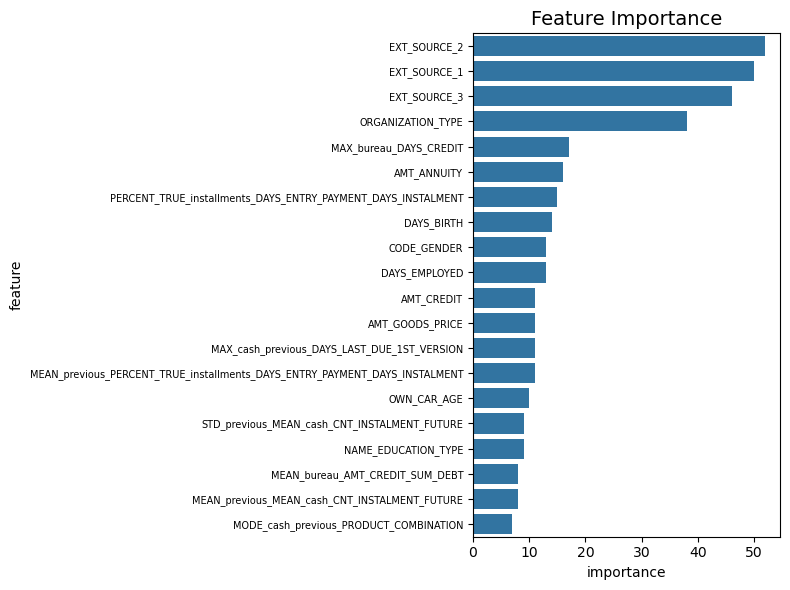

In [85]:
features_importance = pd.DataFrame(
    {
        'importance': lgbm_model.feature_importances_,
        'feature': lgbm_model.feature_name_
    }
)
features_importance_plot = features_importance.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(8, 6), dpi=100) 
sns.barplot(data=features_importance_plot, x='importance', y='feature')

plt.yticks(fontsize=7) # 进一步微调
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()

In [86]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


In [87]:
lgbm_model_pred = lgbm_model.predict_proba(test_features)

In [88]:
submit_df = submit(test['SK_ID_CURR'], lgbm_model_pred[:, 1], 
    name='lgbm_baseline',
    feature_count=train_features.shape[1]
    )
submit_df.head()


,SK_ID_CURR,TARGET
307511,100001,0.072112
307512,100005,0.162662
307513,100013,0.029653
307514,100028,0.034053
307515,100038,0.139559


得分76，差不多